In [3]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict

In [15]:
class BMI_Calc(TypedDict):

    weight : float
    height: float 
    Bmi:float
    Label:str 

In [16]:
def bmi_calculater(State: BMI_Calc) ->BMI_Calc:
    weight=State['weight']
    height=State['height']
    bmi=weight/(height**2)
    State['Bmi']=round(bmi,2)
    return State

In [17]:
def label(State: BMI_Calc) -> BMI_Calc:
    bmi=State['Bmi']
    if bmi < 18.5:
     State["Bmi"]="Underweight"
    elif bmi < 25:
        State["Bmi"]="Normal weight"
    elif bmi < 30:
        State["Bmi"]="Overweight"
    else:
        State["Bmi"]="Obese"

    return State

In [21]:
graph= StateGraph(BMI_Calc)

graph.add_node("BMI calculator",bmi_calculater)
graph.add_node("bmi_label", label)

graph.add_edge(START, "BMI calculator")
graph.add_edge("BMI calculator","bmi_label")
graph.add_edge("BMI calculator",END)

workflow=graph.compile()

In [24]:
intial_state={"weight":79,"height":1.74}

In [25]:
output_state=workflow.invoke(intial_state)
print(output_state)

{'weight': 79, 'height': 1.74, 'Bmi': 'Overweight'}


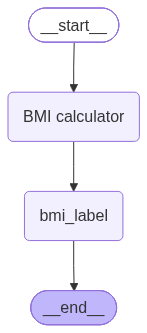

In [26]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())